# **Variance analysis of embeddings**

In [1]:
# Import libraries
import spatialdata as sd
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

In [2]:
# Function to analyze embedding variance
def analyze_embedding_variance(
    adata,
    save_csv=None,
    leiden_resolution=0.5,
    use_rep="X",
    top_k=5,
    plot=True,
):
    """
    Compute per-dimension variance for embeddings in adata.X and ensure
    PCA, neighbors, UMAP, and Leiden exist if missing.
    """

    # Add missing analysis steps only if they are not already present
    if "pca" not in adata.uns or "X_pca" not in adata.obsm:
        sc.pp.pca(adata)

    if "connectivities" not in adata.obsp or "neighbors" not in adata.uns:
        sc.pp.neighbors(adata, use_rep=use_rep)

    if "X_umap" not in adata.obsm:
        sc.tl.umap(adata)

    if "leiden" not in adata.obs:
        sc.tl.leiden(adata, resolution=leiden_resolution)

    # Embedding variance
    embedding_variance = np.var(adata.X, axis=0)

    # Rank the embedding variance
    variance_df = (
        pd.DataFrame(
            {
                "dimension": np.arange(adata.n_vars),
                "variance": embedding_variance,
            }
        )
        .sort_values("variance", ascending=False)
        .reset_index(drop=True)
    )

    if save_csv is not None:
        variance_df.to_csv(save_csv, index=False)

    # Add top variance dimensions to obs for plotting
    top_dims = variance_df.head(top_k)["dimension"].astype(int).tolist()
    for dim in top_dims:
        adata.obs[f"Embedding_{dim}"] = adata.X[:, dim]

    if plot:
        plt.figure(figsize=(10, 4))
        plt.plot(variance_df["variance"].values, linewidth=2)
        plt.xlabel("Embedding dimension rank")
        plt.ylabel("Variance")
        plt.title("Variance ranking of embedding dimensions")
        plt.grid(alpha=0.3)
        plt.show()

        plt.figure(figsize=(8, 4))
        explained = adata.uns["pca"]["variance_ratio"]
        plt.bar(np.arange(1, len(explained) + 1), explained, edgecolor="black")
        plt.plot(np.arange(1, len(explained) + 1), explained, color="red", marker="o", linewidth=1)
        plt.xlabel("Principal Component")
        plt.ylabel("Explained Variance Ratio")
        plt.title("Scree Plot")
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return adata, variance_df

In [14]:
# PCA loadings plot

def plot_pca_loadings(loadings, pc=0, top_n=20):
    pc_loadings = np.abs(loadings[:, pc])
    idx = np.argsort(pc_loadings)[::-1][:top_n]

    plt.figure(figsize=(10, 4))
    plt.bar(np.arange(top_n), pc_loadings[idx], edgecolor="black")
    plt.xticks(np.arange(top_n), idx, rotation=90)
    plt.xlabel("Embedding dimension")
    plt.ylabel(f"|Loading| for PC{pc + 1}")
    plt.title(f"Top {top_n} PCA loadings for PC{pc + 1}")
    plt.tight_layout()
    plt.show()

## **Variance analysis of ConvNeXt embeddings**

In [2]:
# Load the saved Spatialdata object
sdata = sd.read_zarr(
    "../data/results/xenium_dapi_cellfeaturizer.sdata.zarr"
)

print(sdata)

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/results/xenium_dapi_cellfeaturizer.sdata.zarr
├── Images
│     └── 'input_image': DataTree[cyx] (1, 4500, 4000), (1, 2250, 2000), (1, 562, 500), (1, 70, 62)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (4500, 4000), (2250, 2000), (562, 500), (70, 62)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      ├── 'CellFeaturizer_nucleus': AnnData (4063, 7)
      ├── 'ConvNeXtFeaturizer_Ch1_nucleus': AnnData (4063, 2048)
      ├── 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus': AnnData (4063, 2)
      └── 'ViT-MAE_pretrained_PooledEmbeddings': AnnData (4063, 768)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)


In [3]:
print(sdata.tables.keys())

dict_keys(['CellFeaturizer_nucleus', 'ConvNeXtFeaturizer_Ch1_nucleus', 'MLClusterClassifier_Autophagy_15h_classifier2_1_forward_nucleus', 'ViT-MAE_pretrained_PooledEmbeddings'])


In [12]:
# Load the Anndata object containing the ConvNeXt embeddings
embedding_name = "ConvNeXtFeaturizer_Ch1_nucleus"

adata = sdata.tables[embedding_name]

print(adata)

AnnData object with n_obs × n_vars = 4063 × 2048
    obs: 'scportrait_cell_id', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


In [13]:
# Verify the data
print(f"Cells               : {adata.n_obs}")
print(f"Embedding dimensions: {adata.n_vars}")

print()

print("Shape :", adata.X.shape)
print("dtype :", adata.X.dtype)

print()

print("Min :", adata.X.min())
print("Max :", adata.X.max())
print("Mean:", adata.X.mean())
print("Std :", adata.X.std())

Cells               : 4063
Embedding dimensions: 2048

Shape : (4063, 2048)
dtype : float32

Min : -1.8570575
Max : 1.3754599
Mean: -0.0047801877
Std : 0.16139874


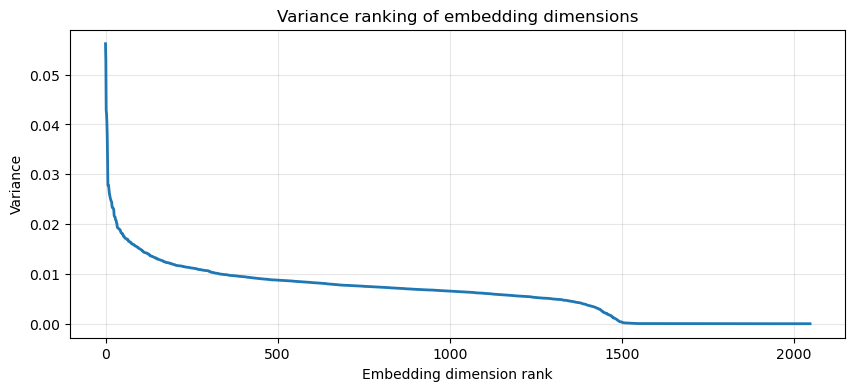

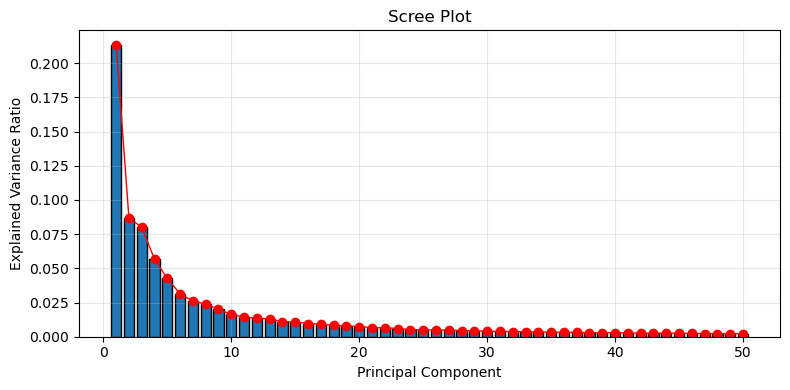

In [24]:
_, variance_df = analyze_embedding_variance(adata,
                                            save_csv="../data/results/convnext_embedding_dimension_variance_for_dapisegmentation.csv",
                                            leiden_resolution=0.5,
                                            use_rep="X",
                                            top_k=5,
                                            plot=True
                                            )

In [25]:
adata.obs.head()

,scportrait_cell_id,region,leiden,Embedding_379,Embedding_1161,Embedding_46,Embedding_1858,Embedding_967
0,1,seg_all_nucleus,1,0.760874,-0.863906,-0.893161,1.142574,-0.035440
1,2,seg_all_nucleus,1,0.935758,-0.761627,-0.544305,0.667770,0.236115
2,3,seg_all_nucleus,1,0.383965,-0.429979,-0.724807,0.663208,0.220299
3,4,seg_all_nucleus,1,0.780501,-0.504971,-0.965522,0.771509,0.101682
4,5,seg_all_nucleus,1,0.175265,-0.731740,-0.743263,0.590378,-0.110610


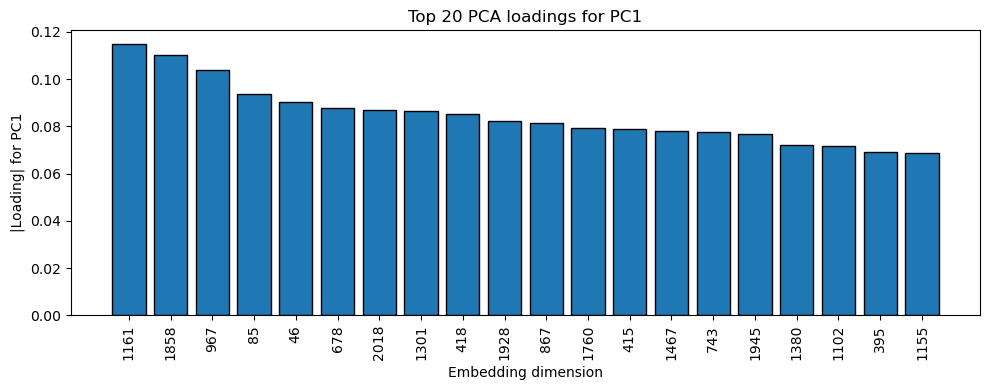

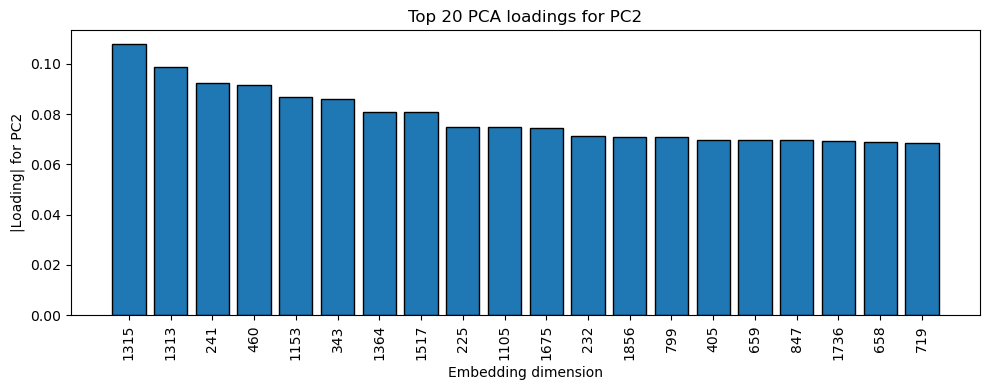

In [26]:
# PCA lodings plot
loadings = adata.varm["PCs"]  # shape: (n_dims, n_pcs)
plot_pca_loadings(loadings, pc=0, top_n=20)
plot_pca_loadings(loadings, pc=1, top_n=20)

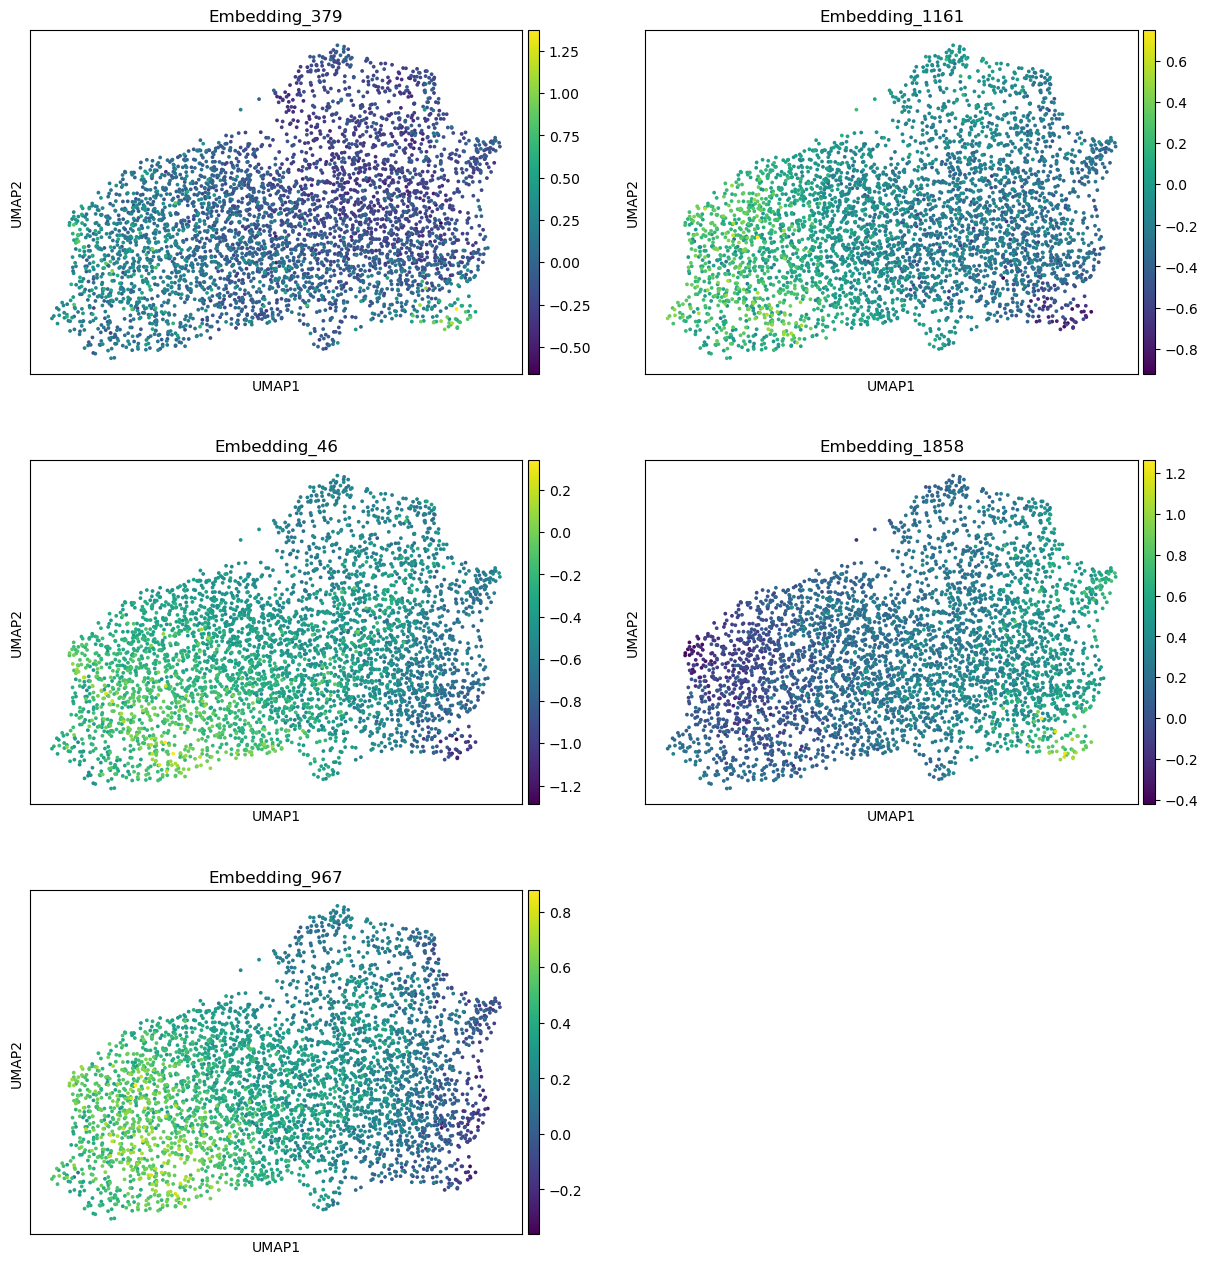

In [27]:
top5 = variance_df.head(5)["dimension"].astype(int)

sc.pl.umap(
    adata,
    color=[f"Embedding_{d}" for d in top5],
    cmap="viridis",
    ncols=2
)

## **Variance analysis of ViT-MAE embeddings**

In [4]:
# Load the Anndata object containing the ViT-MAE patch embeddings
embedding_name = "ViT-MAE_pretrained_PooledEmbeddings"

adata = sdata.tables[embedding_name]

print(adata)

AnnData object with n_obs × n_vars = 4063 × 768
    obs: 'label', 'cell_id', 'leiden'
    uns: 'neighbors', 'leiden_colors', 'leiden', 'umap', 'pca'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'


In [5]:
# Verify the data
print(f"Cells               : {adata.n_obs}")
print(f"Embedding dimensions: {adata.n_vars}")

print()

print("Shape :", adata.X.shape)
print("dtype :", adata.X.dtype)

print()

print("Min :", adata.X.min())
print("Max :", adata.X.max())
print("Mean:", adata.X.mean())
print("Std :", adata.X.std())

Cells               : 4063
Embedding dimensions: 768

Shape : (4063, 768)
dtype : float32

Min : -4.7414675
Max : 4.345837
Mean: -0.0053976043
Std : 0.32922462


In [6]:
print(adata.obs.head())

   label  cell_id leiden
0    0.0        1      3
1    0.0        2      3
2    0.0        3      3
3    0.0        4      3
4    0.0        5      3


In [7]:
# Compute embedding variance across all cells
embedding_variance = np.var(
    adata.X,
    axis=0
)

In [8]:
# Rank embedding dimensions
variance_df = pd.DataFrame({

    "dimension": np.arange(adata.n_vars),

    "variance": embedding_variance

})

variance_df = variance_df.sort_values(
    "variance",
    ascending=False
)

variance_df.head(20)

,dimension,variance
103,103,0.461557
457,457,0.011910
304,304,0.008111
223,223,0.007334
558,558,0.007279
383,383,0.006825
584,584,0.005975
297,297,0.005459
687,687,0.005374
260,260,0.005093


In [9]:
# Save the ranking to a CSV file
variance_df.to_csv(
    "../data/results/vit_mae_embedding_dimension_variance_for_dapisegmentation.csv",
    index=False
)

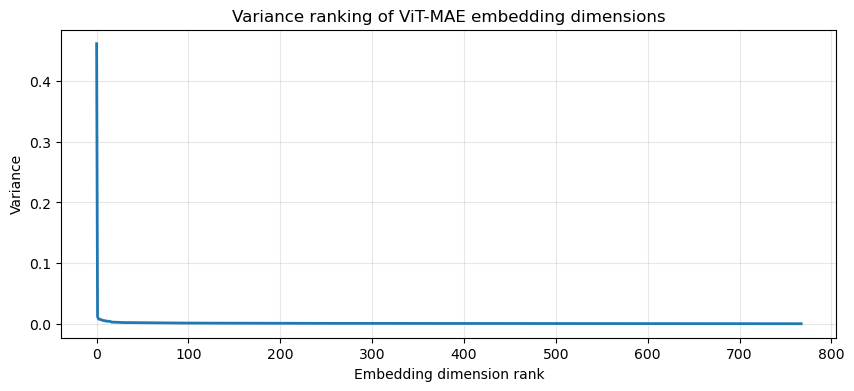

In [10]:
# Plot ranked variance
plt.figure(figsize=(10,4))

plt.plot(
    variance_df["variance"].values,
    linewidth=2
)

plt.xlabel("Embedding dimension rank")
plt.ylabel("Variance")

plt.title("Variance ranking of ViT-MAE embedding dimensions")

plt.grid(alpha=0.3)

plt.show()

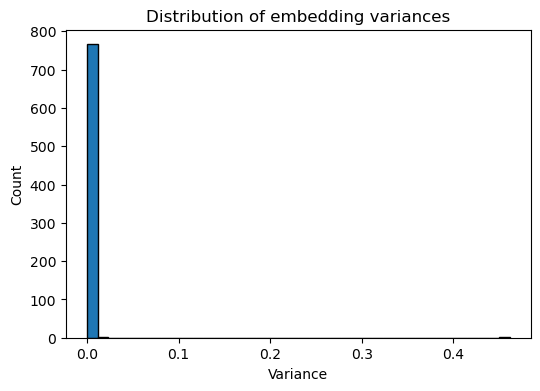

In [11]:
# Distribution of variances
plt.figure(figsize=(6,4))

plt.hist(
    embedding_variance,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Variance")
plt.ylabel("Count")

plt.title("Distribution of embedding variances")

plt.show()

In [12]:
# PCA explained variance
explained = adata.uns["pca"]["variance_ratio"]

print(explained[:20])

[0.63005024 0.1237101  0.05372816 0.02777033 0.02349702 0.0188478
 0.01441148 0.01190415 0.00976376 0.00921622 0.00751091 0.00550532
 0.00435137 0.00359441 0.00326165 0.002827   0.00277887 0.00239464
 0.00226731 0.00198766]


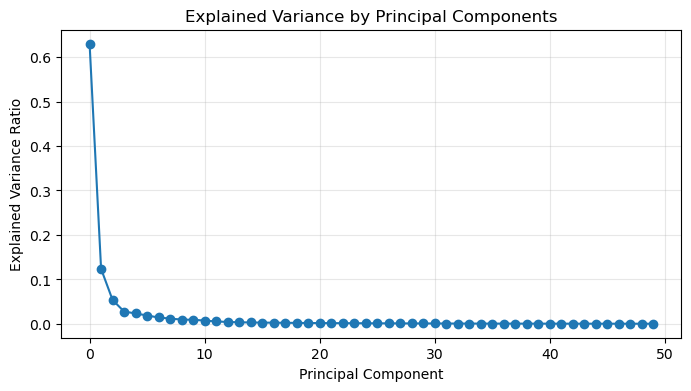

In [ ]:
# Plot explained variance
plt.figure(figsize=(8,4))

plt.plot(
    explained,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")

plt.title("Explained Variance by Principal Components")

plt.grid(alpha=0.3)

plt.show()

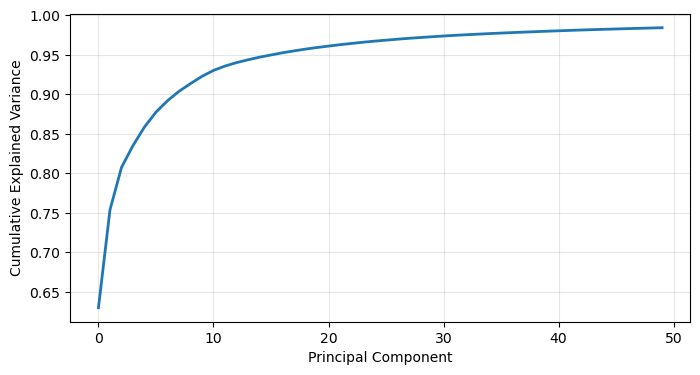

In [14]:
# Cumulative explained variance
cumulative = np.cumsum(explained)

plt.figure(figsize=(8,4))

plt.plot(
    cumulative,
    linewidth=2
)

plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")

plt.grid(alpha=0.3)

plt.show()

In [15]:
# PCA loadings
loadings = adata.varm["PCs"]

print(loadings.shape)

(768, 50)


In [16]:
# Top contributors to PC1
pc1 = np.abs(loadings[:,0])

pc1_df = pd.DataFrame({

    "dimension": np.arange(768),

    "loading": pc1

})

pc1_df = pc1_df.sort_values(
    "loading",
    ascending=False
)

pc1_df.head(20)

,dimension,loading
103,103,0.826971
457,457,0.109989
223,223,0.095230
584,584,0.087096
558,558,0.075600
260,260,0.072752
540,540,0.070420
318,318,0.060409
208,208,0.057884
687,687,0.055476


In [17]:
# Top contributors to PC2
pc2 = np.abs(loadings[:,1])

pc2_df = pd.DataFrame({

    "dimension": np.arange(768),

    "loading": pc2

})

pc2_df = pc2_df.sort_values(
    "loading",
    ascending=False
)

pc2_df.head(20)

,dimension,loading
304,304,0.168086
331,331,0.167953
306,306,0.124850
19,19,0.119545
326,326,0.111050
529,529,0.110824
297,297,0.106313
315,315,0.104453
593,593,0.095314
103,103,0.094036


In [18]:
# Summary Table
summary = pd.DataFrame({

    "dimension": np.arange(768),

    "variance": embedding_variance,

    "PC1_loading": np.abs(loadings[:,0]),

    "PC2_loading": np.abs(loadings[:,1]),

    "PC3_loading": np.abs(loadings[:,2])

})

summary = summary.sort_values(
    "variance",
    ascending=False
)

summary.head(20)

,dimension,variance,PC1_loading,PC2_loading,PC3_loading
103,103,0.461557,0.826971,0.094036,0.186636
457,457,0.011910,0.109989,0.062151,0.194007
304,304,0.008111,0.016127,0.168086,0.222923
223,223,0.007334,0.095230,0.003124,0.026249
558,558,0.007279,0.075600,0.068281,0.124710
383,383,0.006825,0.022937,0.008071,0.074772
584,584,0.005975,0.087096,0.020621,0.012978
297,297,0.005459,0.029979,0.106313,0.028586
687,687,0.005374,0.055476,0.036705,0.152385
260,260,0.005093,0.072752,0.030212,0.035628


In [19]:
summary.to_csv(
    "../data/results/vit_mae_embedding_variance_summary_dapisegmentation.csv",
    index=False
)

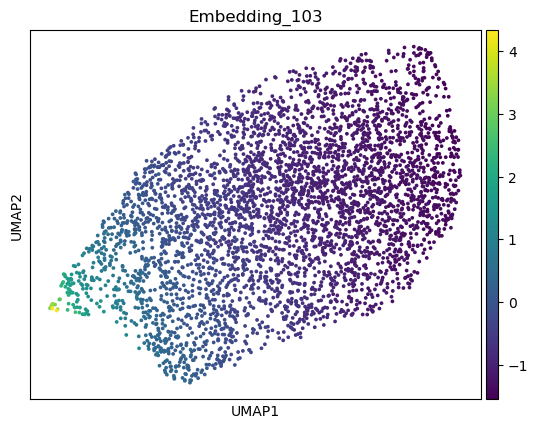

In [20]:
# Visualize the highest-variance embedding on the existing UMAP
top_dim = int(variance_df.iloc[0]["dimension"])

adata.obs[f"Embedding_{top_dim}"] = adata.X[:, top_dim]

sc.pl.umap(
    adata,
    color=f"Embedding_{top_dim}",
    cmap="viridis"
)

In [ ]:
# Visualize the top 5 embedding dimensions
top5 = variance_df.head(5)["dimension"].astype(int)

for dim in top5:
    adata.obs[f"Embedding_{dim}"] = adata.X[:, dim]

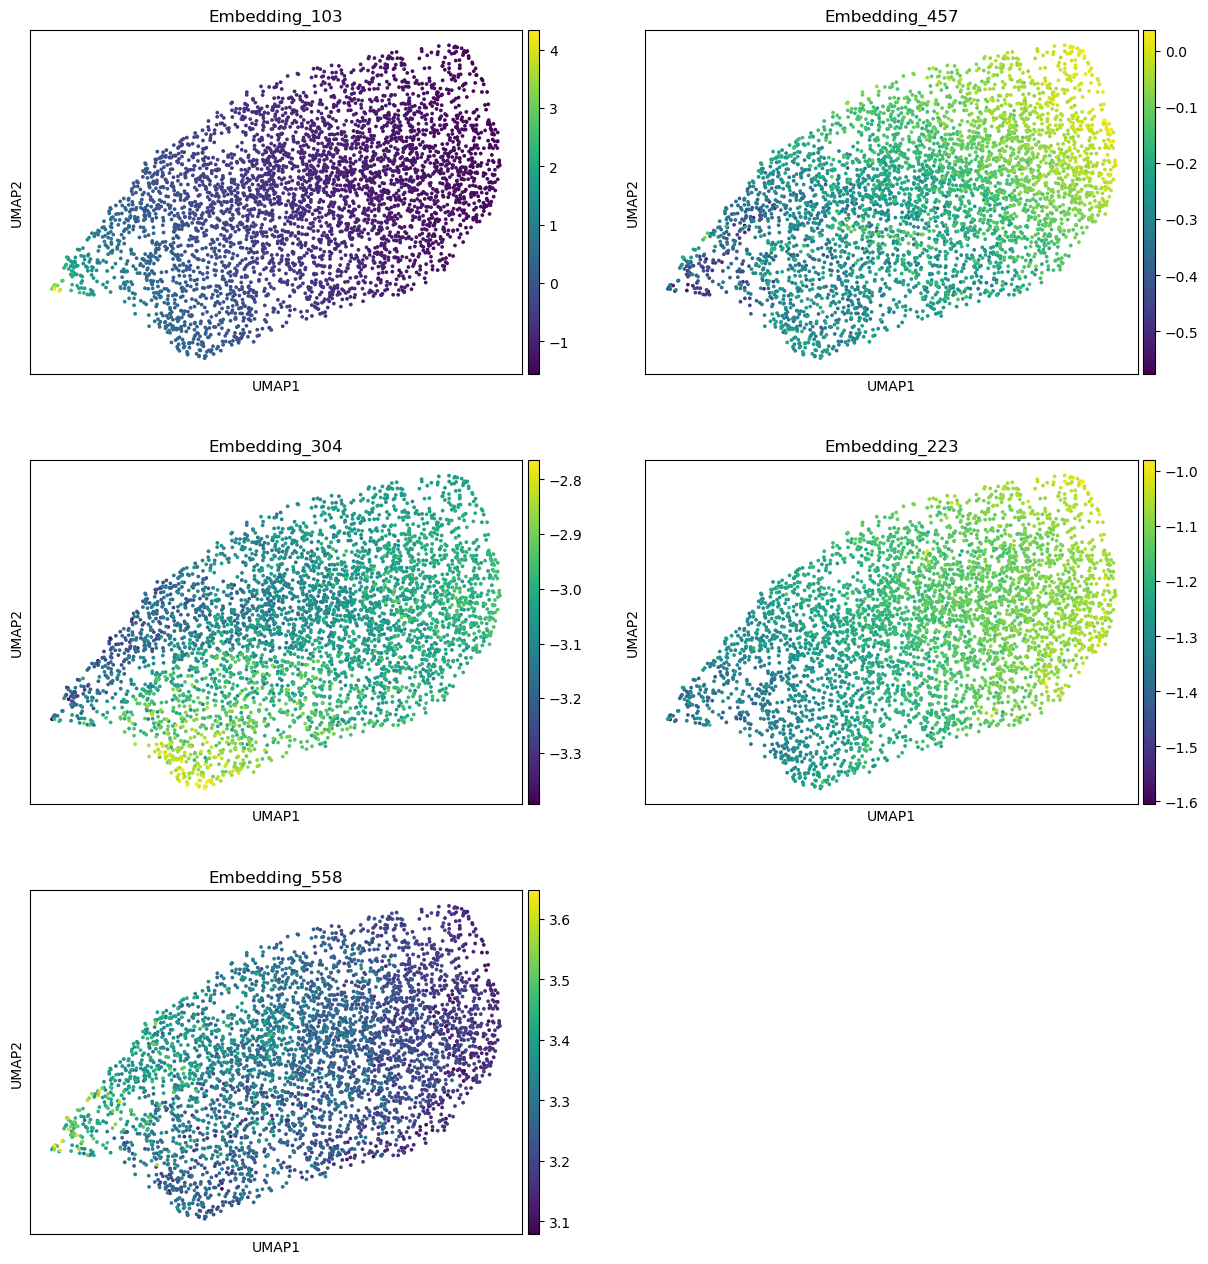

In [22]:
sc.pl.umap(
    adata,
    color=[f"Embedding_{d}" for d in top5],
    cmap="viridis",
    ncols=2
)

## **Variance analysis of ConvNeXt embeddings (full dataset)**

In [4]:
# Load the saved Spatialdata object
sdata = sd.read_zarr(
    "../data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_full_project/scportrait.sdata"
)

print(sdata)

SpatialData object, with associated Zarr store: /scratch/tmurugan/scportrait-spatial-omics-qc/data/interim/10x_xenium_breast_cancer_rep1_dapisegmentation_full_project/scportrait.sdata
├── Images
│     └── 'input_image': DataTree[cyx] (1, 25778, 35416), (1, 12889, 17708), (1, 3222, 4427), (1, 402, 553)
├── Labels
│     └── 'seg_all_nucleus': DataTree[yx] (25778, 35416), (12889, 17708), (3222, 4427), (402, 553)
├── Points
│     └── 'centers_seg_all_nucleus': DataFrame with shape: (<Delayed>, 2) (2D points)
└── Tables
      ├── 'CellFeaturizer_nucleus': AnnData (167873, 7)
      └── 'ConvNeXtFeaturizer_Ch1_nucleus': AnnData (167873, 2048)
with coordinate systems:
    ▸ 'global', with elements:
        input_image (Images), seg_all_nucleus (Labels), centers_seg_all_nucleus (Points)


In [5]:
print(sdata.tables.keys())

dict_keys(['CellFeaturizer_nucleus', 'ConvNeXtFeaturizer_Ch1_nucleus'])


In [6]:
# Load the Anndata object containing the ConvNeXt embeddings
embedding_name = "ConvNeXtFeaturizer_Ch1_nucleus"

adata = sdata.tables[embedding_name]

print(adata)

AnnData object with n_obs × n_vars = 167873 × 2048
    obs: 'scportrait_cell_id', 'region'
    uns: 'spatialdata_attrs'
    obsm: 'spatial'


In [7]:
# Verify the data
print(f"Cells               : {adata.n_obs}")
print(f"Embedding dimensions: {adata.n_vars}")

print()

print("Shape :", adata.X.shape)
print("dtype :", adata.X.dtype)

print()

print("Min :", adata.X.min())
print("Max :", adata.X.max())
print("Mean:", adata.X.mean())
print("Std :", adata.X.std())

Cells               : 167873
Embedding dimensions: 2048

Shape : (167873, 2048)
dtype : float32

Min : -2.2244885
Max : 1.6921943
Mean: -0.004667395
Std : 0.16099693


/tmp/ipykernel_3183106/288411631.py:26: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=leiden_resolution)


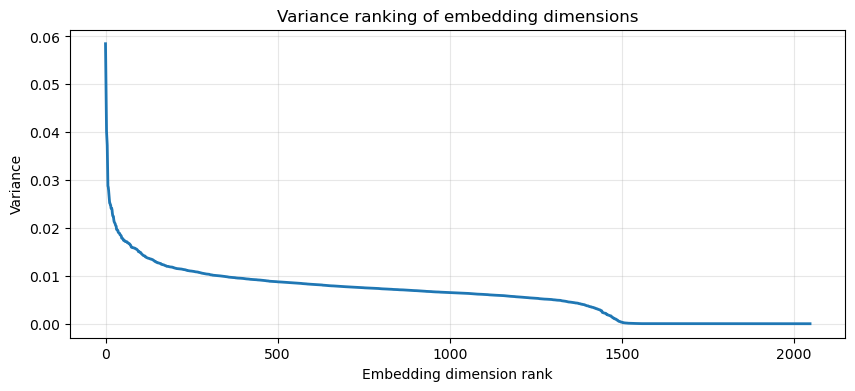

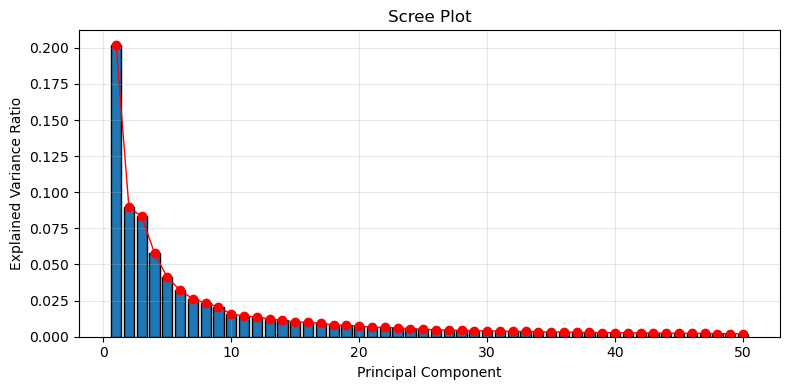

In [8]:
_, variance_df = analyze_embedding_variance(adata,
                                            save_csv="../data/results/fulldataset_convnext_embedding_dimension_variance_for_dapisegmentation.csv",
                                            leiden_resolution=0.5,
                                            use_rep="X",
                                            top_k=5,
                                            plot=True
                                            )

In [9]:
adata.obs.head()

,scportrait_cell_id,region,leiden,Embedding_379,Embedding_1161,Embedding_46,Embedding_1858,Embedding_85
0,1,seg_all_nucleus,2,0.718843,-0.210449,-0.339138,0.386916,0.363071
1,2,seg_all_nucleus,3,0.202750,-0.584776,-0.578153,0.949184,0.662849
2,3,seg_all_nucleus,3,0.353960,-0.237061,-0.533087,0.803873,0.488462
3,4,seg_all_nucleus,0,0.323528,-0.392649,-0.577031,0.659465,0.390607
4,5,seg_all_nucleus,3,0.482370,-0.507429,-0.687580,0.629185,0.600738


In [11]:
adata

AnnData object with n_obs × n_vars = 167873 × 2048
    obs: 'scportrait_cell_id', 'region', 'leiden', 'Embedding_379', 'Embedding_1161', 'Embedding_46', 'Embedding_1858', 'Embedding_85'
    uns: 'spatialdata_attrs', 'pca', 'neighbors', 'umap', 'leiden'
    obsm: 'spatial', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

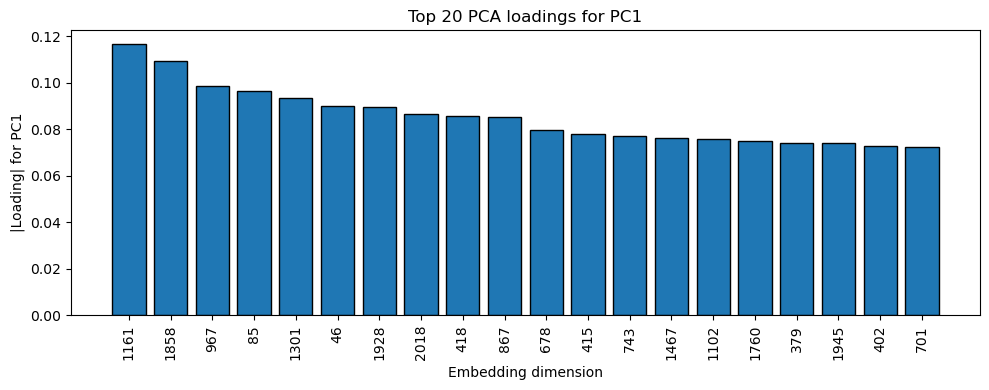

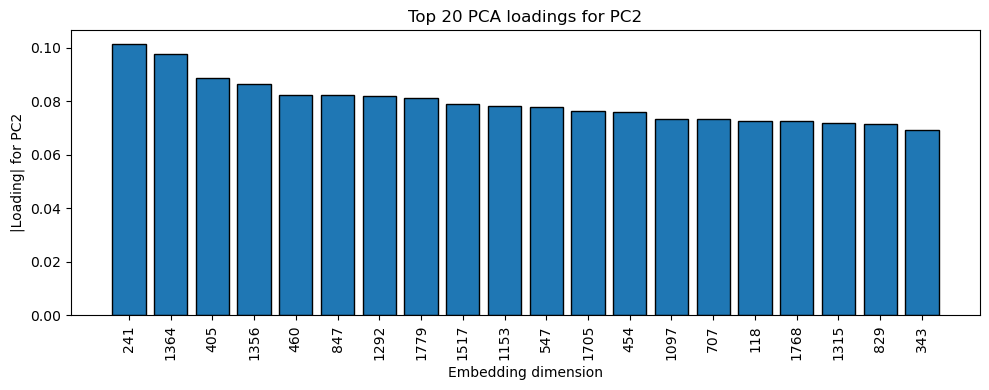

In [15]:
# PCA loadings plot
loadings = adata.varm["PCs"]  # shape: (n_dims, n_pcs)
plot_pca_loadings(loadings = loadings, pc=0, top_n=20)
plot_pca_loadings(loadings = loadings, pc=1, top_n=20)

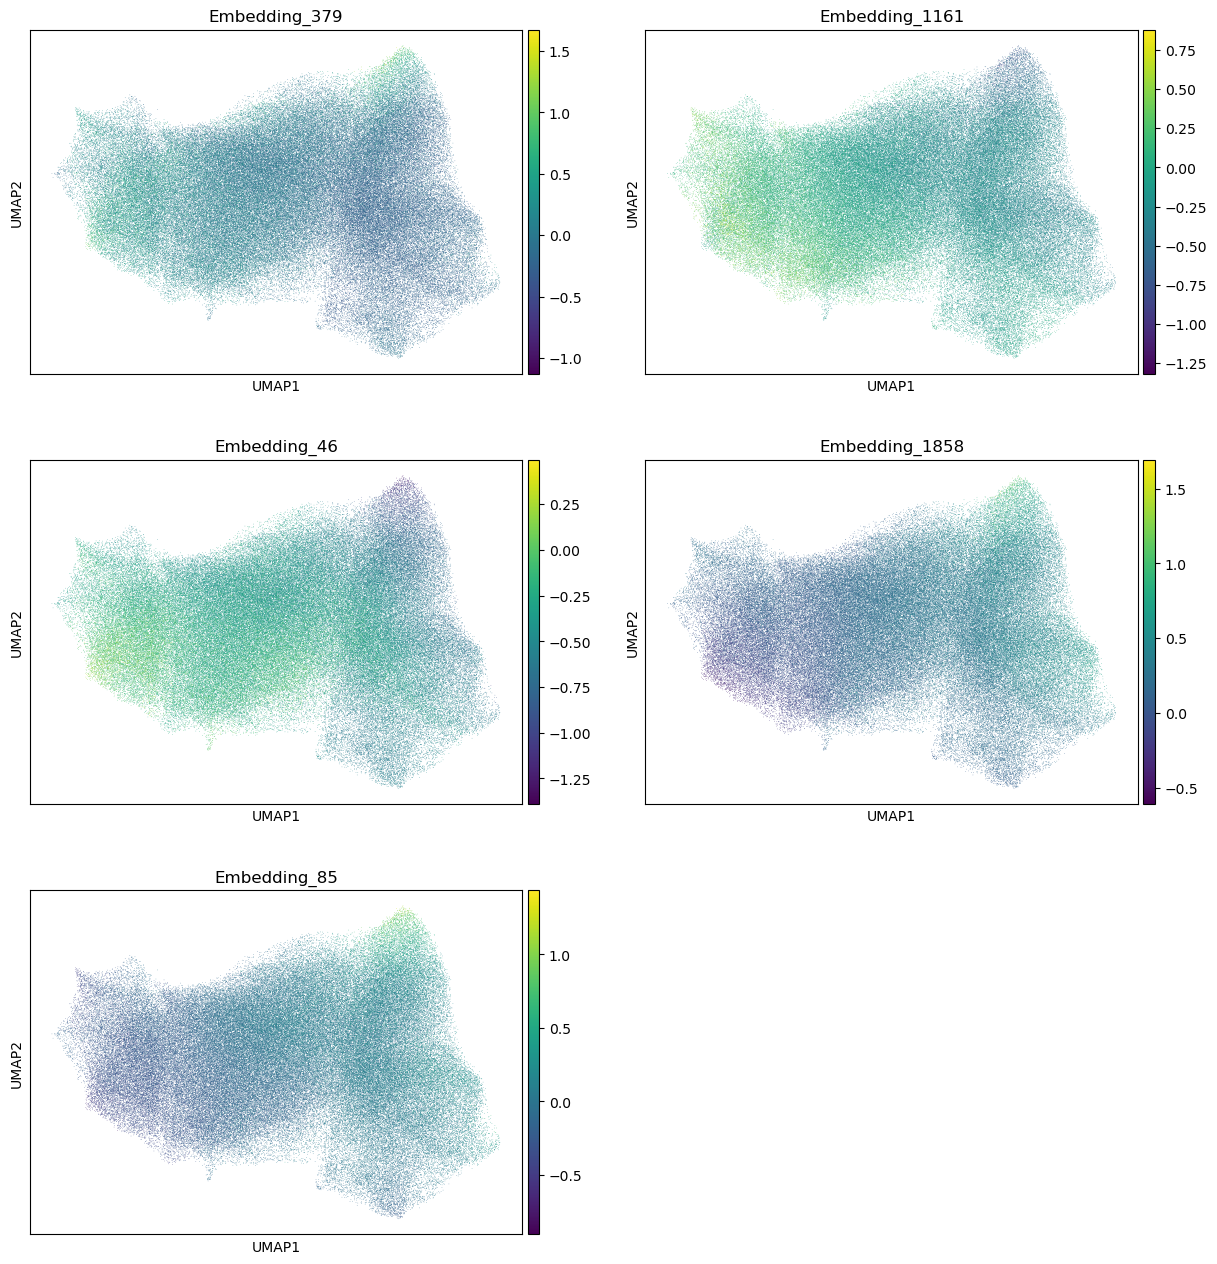

In [16]:
top5 = variance_df.head(5)["dimension"].astype(int)

sc.pl.umap(
    adata,
    color=[f"Embedding_{d}" for d in top5],
    cmap="viridis",
    ncols=2
)